# Planning

Planning a course of action is a key requirement for an intelligent agent. **Classical planning** is defined as the task of **finding a sequence of actions to accomplish a goal** in a **discrete, deterministic, static, fully observable environment**. We have seen two approaches to this task: the search-based agent and the propositionsl logic agent. Both share two limitations. First, they rely on **domain-specific heuristics** or** hand-crafted rules**. Each new problem domain requires new heuristic functions or new logical axioms. Second, they require an **explicit enumeration of an exponentially large state space**. For example, in a propositional logic model of the Wumpus World, the axiom for moving forward must be repeated for each of the agent’s four orientations, at every time step, and for each possible position. To overcome these limitations, the planning community developed a factored representation using a family of languages known as [**Planning Domain Definition Language (PDDL)](/papers/(1998)%20-%20The%20Planning%20Domain%20Definition%20Language.pdf. PDDL allows planners to express entire classes of actions compactly and it removes the need for handcrafted, domain-specific logic.

## PDDL

The **Planning Domain Definition Language** is a formal language for specifying planning problems, that is, problems where an agent must determine a sequence of actions to transition from an initial state to a goal state. For example, we can consider the Vacuum-cleaner World:

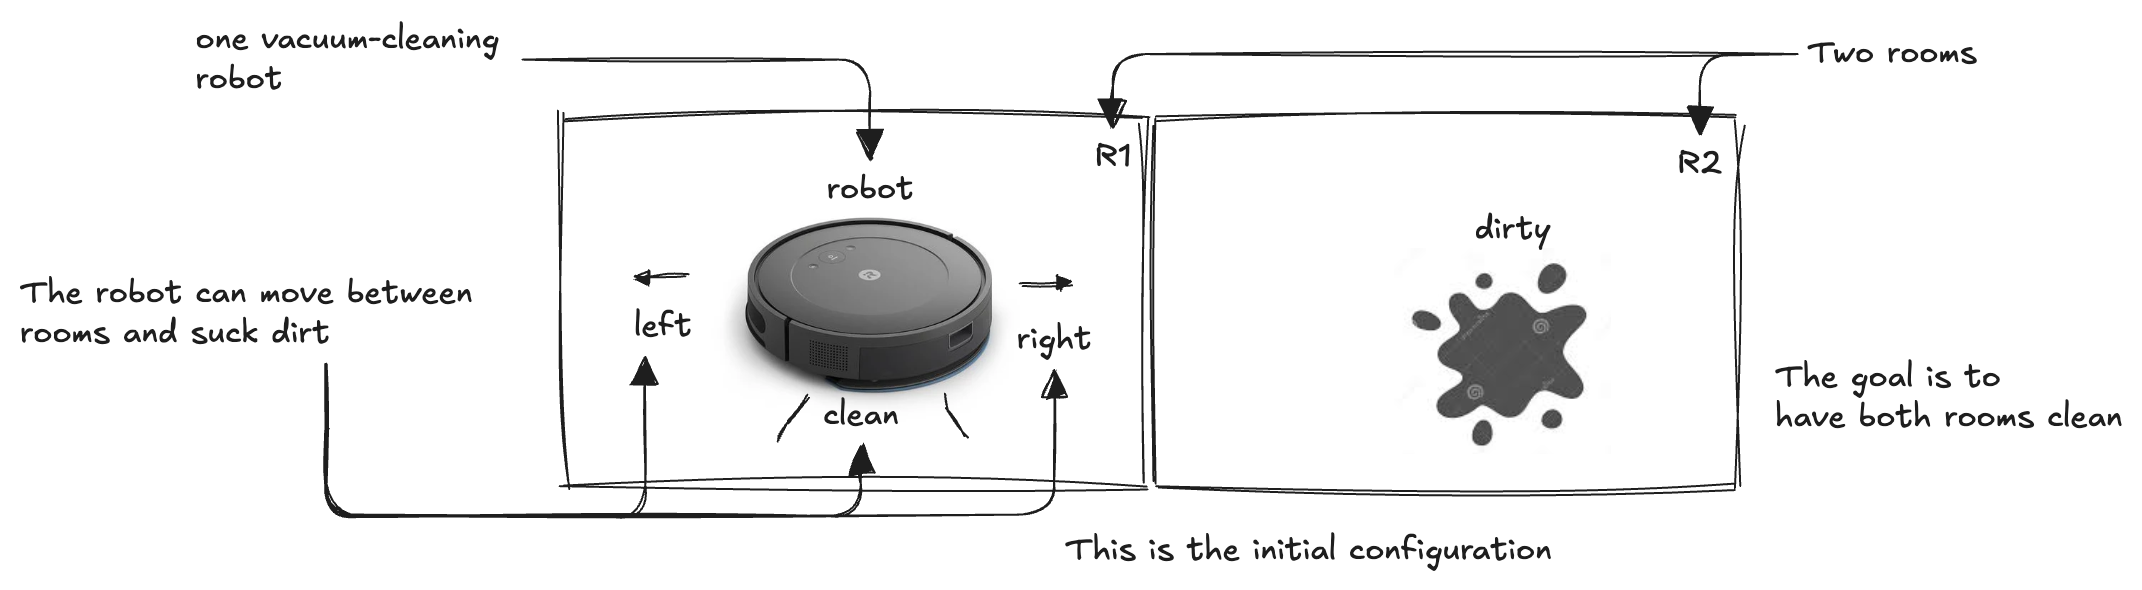

The language was developed to serve as a common representation standard for the automated planning community and has been widely adopted, particularly in the International Planning Competitions (IPC). PDDL allows us to define:
- The **initial state** of the world,
- The **goal condition** that must be achieved,
- The **set of actions available**, each with its own preconditions and effects.

PDDL is a **declarative language**, meaning it specifies what the world is like (in terms of facts and conditions) rather than how to achieve goals procedurally. Furthermore, it is **domain-independent**, meaning the same planning algorithms can operate on any problem encoded in PDDL, whether it describes robot navigation, logistics, or puzzle solving. The original syntax of PDDL was based on Lisp (using parenthesized prefix notation), but we will use a more Pythonic syntax for readability and ease of use.

### Objects, Predicates and Fluents

**Objects** are constant values used to denote concrete entities in the world, such as specific locations or items.

In [203]:
class Object:
    def __init__(self, name):
        self.name = name

    def __str__(self):
        return self.name

    def __repr__(self):
        return self.name

For example, in the Vacuum-cleaner world, we might have:

In [204]:
Robot = Object("Robot")
R1 = Object("R1")
R2 = Object("R2")
Dirty = Object("Dirt")

A **predicate** is a symbolic template that represents a **property** or a **relationship** between objects. It defines the structure of a condition, but not its content. A predicate is not tied to any specific object, it becomes meaningful only when applied to objects. for example, the predicate "In(x, y)" can be used to express that an object "x" is located at position "y".

In [205]:
class Predicate:
    def __init__(self, name, arity):
        self.name = name
        self.arity = arity

    def __str__(self):
        return f"{self.name}/{self.arity}"

    def __repr__(self):
        return str(self)

For example, in the Vacuum-cleaner world, we might have a predicate for the location of an objecta and a predicate for the cleanliness of a room:

In [206]:
In = Predicate("In", 2)
Clean = Predicate("Clean", 1)

A **fluent** is a concrete instance of a predicate applied to specific objects. It represents a **fact** that can be true or false in a given world state, and it **may change over time**. Fot example "It(Robot, R1)" is a fluent saying "the robot is in room R1":

In [207]:
class Fluent:
    def __init__(self, predicate, args):
        if len(args) != predicate.arity:
            raise ValueError(f"{predicate.name} expects {predicate.arity} arguments, got {len(args)}.")
        self.predicate = predicate
        self.args = tuple(args)

    def __str__(self):
        return f"{self.predicate.name}({', '.join(map(str, self.args))})"

    def __repr__(self):
        return str(self)

    def __eq__(self, other):
        return (
            isinstance(other, Fluent) and
            self.predicate.name == other.predicate.name and
            self.args == other.args
        )

    def __hash__(self):
        return hash((self.predicate.name, self.args))

For example, in the Vacuum-cleaner world, we might have the following fluents to express that R1 is clean, and that the vacuum cleaner is at R1:

In [208]:
f1 = Fluent(In, [Robot, R1])
f2 = Fluent(Clean, [R1])

print(f1) 
print(f2)  


In(Robot, R1)
Clean(R1)


Each fluent is also said to be **ground**, meaning that **it contains no variables**, every argument of the predicate is a specific, concrete object from the problem domain. The previous example is a ground fluent because both Robot and R1 are actual named objects, not placeholders like x or other variables. 

### State and Goal

The **state** of the world is represented as a set of ground fluents, which can be thought of as a snapshot of the world at a particular time:

In [209]:
class State:
    def __init__(self, fluents):
        self.fluents = set(fluents)

    def is_true(self, fluent):
        return fluent in self.fluents

    def copy(self):
        return State(self.fluents.copy())

    def __str__(self):
        return '{ ' + ', '.join(map(str, sorted(self.fluents, key=str))) + ' }'

This is crucial! States represent **fully specified facts** about the world. A ground fluent captures a particular condition that is either true or false in a given state, there is **no ambiguity or generality**. Grounding eliminates variables, ensuring that agents can reason about precise configurations of the world without the need to interpret or substitute terms at runtime. Consider the state of the Vacuum-cleaner world:

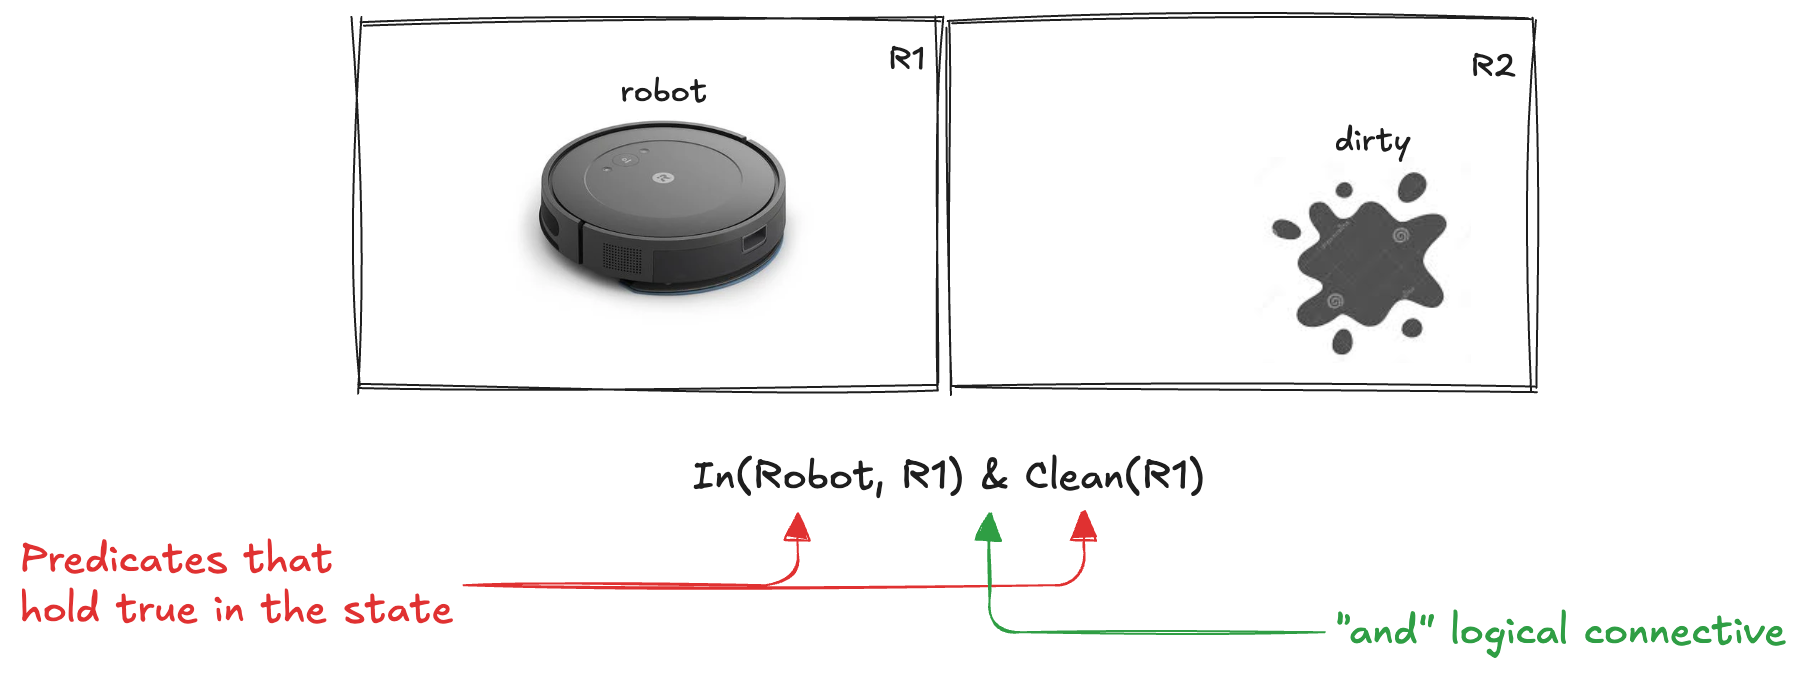

The state is expressed as a conjunction of positive, ground fluent, n**o negations** is not allowed, **no variables** is disallowed, and **no disjunctions**. Additionally, **uncertainty is not represented**: the world is assumed to be fully known and deterministic.

In [210]:
state = State([f1, f2])
print(state)

{ Clean(R1), In(Robot, R1) }


A goal is typically expressed as a **conjunction of fluent**, in the example of the Vacuum-cleaner world, a goal might be to have both rooms clean, represented as a conjunction of positive literals:

In [211]:
goal = {
    Fluent(Clean, [R1]),
    Fluent(Clean, [R2])
}

Since the goal condition specifies what we want to achieve we can have **a list of fluents that must be false** (i.e., absent from the final state), for example in the Vacuum-cleaner world, we might want to ensure that the vacuum cleaner is not at R1:

In [212]:
goal = {
    "positive": [
        Fluent(Clean, [R1]),
        Fluent(Clean, [R2])
    ],
    "negative": [
        Fluent(In, [Robot, R1])
    ]
}

A goal is satisfied in a state if every positive fluent is present in the state and every negative fluent is absent. 

### Action schemas

An **action schema** defines a general **template** for a class of actions. It specifies the conditions under which an action can be applied and how the world changes as a result. The **preconditions** describe what must be true in the current state for the action to be applicable. These include positive preconditions, which are fluents that must be present in the state, and negative preconditions, which are fluents that must be absent. The **effects** describe how the state changes after the action is executed: positive effects are fluents that are added to the state, while negative effects are fluents that are removed. This distinction allows planners to **reason symbolically** about actions and their consequences in a concise and general way:

In [213]:
class ActionSchema:
    def __init__(self, name, parameters, pos_preconditions, neg_preconditions, pos_effects, neg_effects):
        self.name = name
        self.parameters = parameters
        self.pos_preconditions = pos_preconditions    
        self.neg_preconditions = neg_preconditions    
        self.pos_effects = pos_effects                
        self.neg_effects = neg_effects  

Consider the following action schema for moving the vacuum cleaner from one room to another:

In [214]:
Move = ActionSchema(
    name="Move",
    parameters=["robot", "from_room", "to_room"],
    pos_preconditions=[
        Fluent(In, ["robot", "from_room"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(In, ["robot", "to_room"])
    ],
    neg_effects=[
        Fluent(In, ["robot", "from_room"])
    ]
)

### Ground actions

A **ground action** is obtained by **instantiating** an action schema. This is dove by substituting each variable in the schema with a specific object from the domain. The result is a **fully specified action** with no variables, ready to be evaluated and applied in a concrete state:

In [215]:
class GroundedAction:
    def __init__(self, schema, assignment):
        self.schema = schema
        self.assignment = assignment
        self.name = self._make_name()
        self.pos_preconditions = self._substitute_all(schema.pos_preconditions)
        self.neg_preconditions = self._substitute_all(schema.neg_preconditions)
        self.pos_effects = self._substitute_all(schema.pos_effects)
        self.neg_effects = self._substitute_all(schema.neg_effects)

    def _make_name(self):
        args = [str(self.assignment[param]) for param in self.schema.parameters]
        return f"{self.schema.name}({', '.join(args)})"

    def _substitute(self, fluent):
        args = [self.assignment.get(arg, arg) for arg in fluent.args]
        return Fluent(fluent.predicate, args)

    def _substitute_all(self, fluent_list):
        return [self._substitute(f) for f in fluent_list]

    def __str__(self):
        return self.name

For example, to instatiate a move from room R1 to room R2, we can write:

In [216]:
move_from_R1_to_R2 = GroundedAction(Move, {
    "robot": Robot,
    "from_room": R1,
    "to_room": R2
})

print(move_from_R1_to_R2)

Move(Robot, R1, R2)


A ground action is **applicable** in a state if the state **satisfies** all its preconditions: every positive fluent must be present in the state, and every fluent that must not hold (i.e., a negative precondition) must be absent from the state: 

In [217]:
def is_applicable(action, state):
    pos_ok = all(precond in state.fluents for precond in action.pos_preconditions)
    neg_ok = all(precond not in state.fluents for precond in action.neg_preconditions)
    return pos_ok and neg_ok

For example, check if the previous move can be applied in the state where the vacuum cleaner is at R1:


In [218]:
is_applicable_result = is_applicable(move_from_R1_to_R2, state)
print("Is the action applicable?", is_applicable_result)    

Is the action applicable? True


When a ground action is applicable in a given state, executing it produces a **new state** that reflects the changes caused by the action. This new state is obtained by **removing all fluents specified in the negative effects**(also known as the delete list) and **adding all fluents specified in the positive effects** (the add list):

In [219]:
def apply(action, state):

    # Check if the action is applicable before applying it    
    if not is_applicable(action, state):
        raise ValueError(f"Action '{action}' is not applicable in the given state.")

    # Create a new state based on the current state
    new_state = state.copy()

    # Add positive effects
    for fluent in action.neg_effects:
        new_state.fluents.discard(fluent)

    # Remove negative effects
    for fluent in action.pos_effects:
        new_state.fluents.add(fluent)
    
    # Return the new state
    return new_state

For example, we can apply the move action to the previous state:

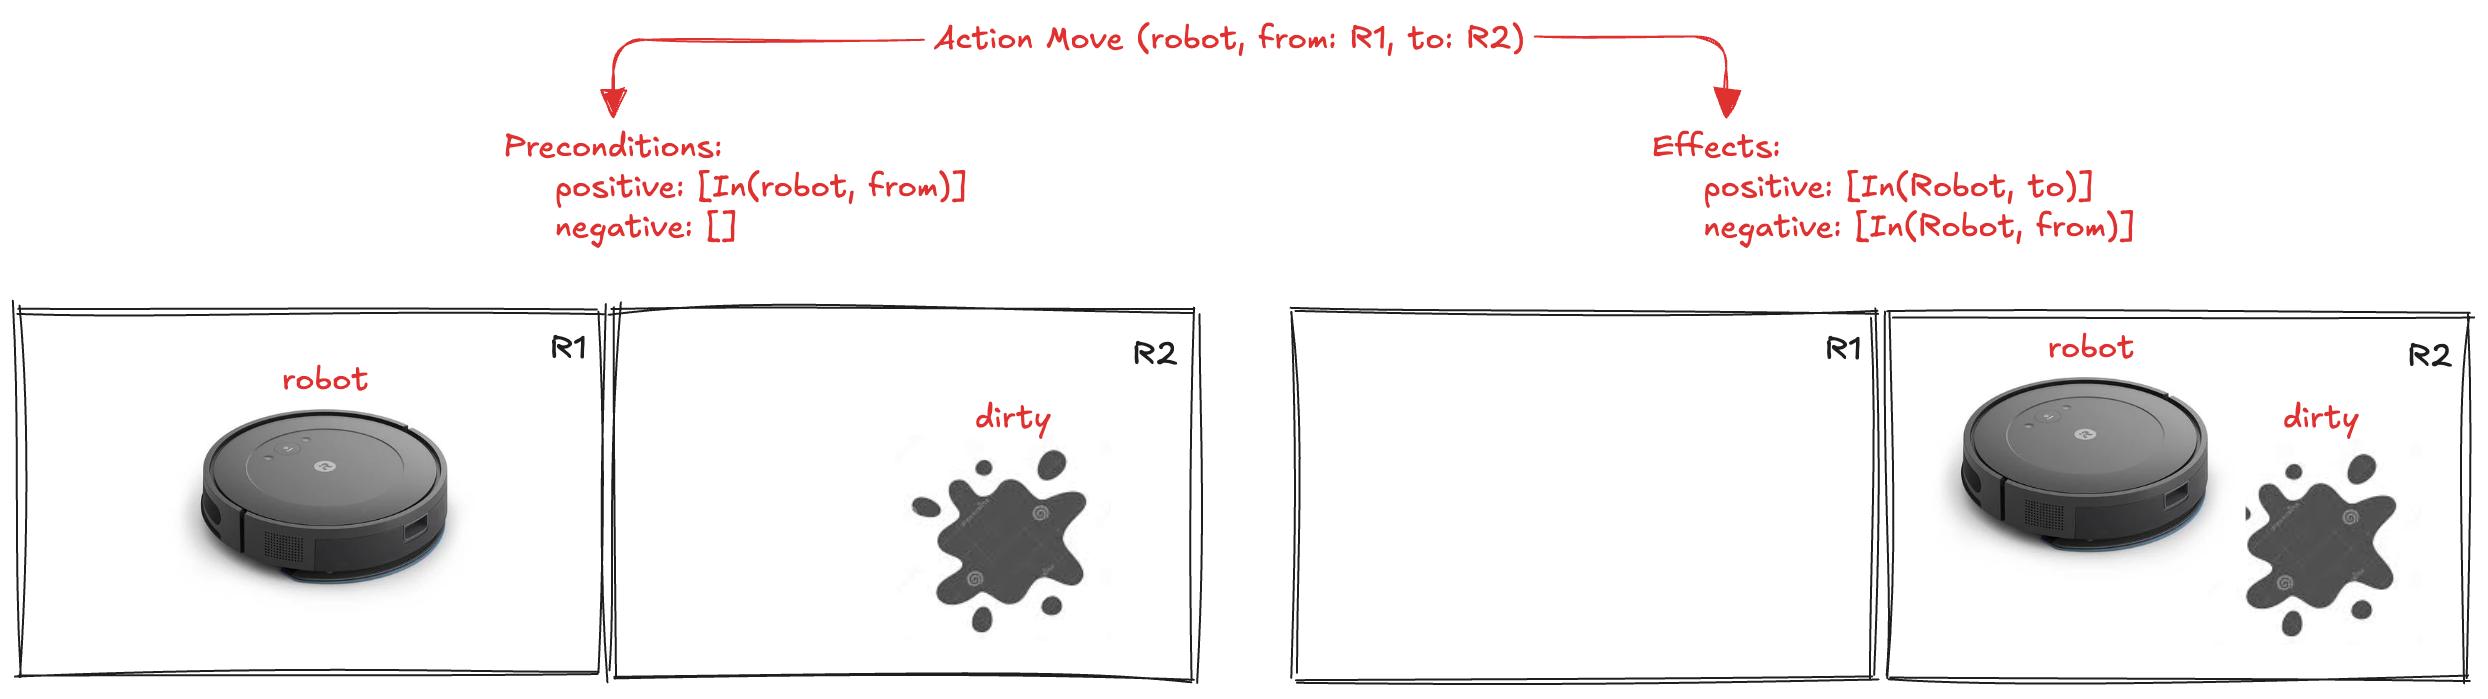

In [220]:
print("Current State:", state)
apply_result = apply(move_from_R1_to_R2, state)
print("New State:", apply_result)

Current State: { Clean(R1), In(Robot, R1) }
New State: { Clean(R1), In(Robot, R2) }


The resulting state would reflect that the robot is no longer at R1 but is now at R2.

### Database semantics

PDDL adopts database semantics, which impose a **set of simplifying assumptions** about how the world is described and understood by the agent. These assumptions help **eliminate ambiguity** and make logical reasoning more tractable:

- The **Unique Names Assumption (UNA)** means that each object refers to a unique, distinct entity. For example, if we have two object R1 and R2, the agent assumes they refer to different rooms, even if we haven’t explicitly stated that they are not equal.
- The **Domain Closure Assumption (DCA)** asserts that the set of all entities in the world is exactly the set of objects defined in the domain and problem description. If an entity isn’t named, it doesn’t exist in the world. This helps the agent reason in a finite and bounded universe, where all entities are known.
- The **Closed-World Assumption (CWA)** means that any fact (fluent) not explicitly listed in the current state is assumed to be false. For example, if the state doesn’t say that R2 is clean, the planner assumes that R2 is dirty. This avoids the need to enumerate every negative fact and ensures the agent doesn’t operate under uncertainty about what is not known.

Together, these assumptions allow the agent to work with **a fully specified and deterministic model of the world**. The agent doesn’t have to ask "could this be true?": if it’s not in the state, it’s false. This makes classical planning simpler, faster, and easier to implement than reasoning in open or uncertain domains.

Moreover, agents should takle the **frame problem**, which is the challenge of specifying what remains unchanged after an action is performed. In logic, when we describe the effects of an action, we need to specify not only what does change, but also that everything else stays the same. For example, if the robot moves from R1 to R2, then: it is in R2, it is not in R1, but what about everything else? Specifying all of that explicitly for every action would be tedious and error-prone. The database semantics of PDDL help us here: we assume that **everything not mentioned in the effects remains unchanged**. This means that if an action doesn’t affect a fluent, we don’t need to state it explicitly. For example, if the robot moves from R1 to R2, we don’t need to say that R2 is still clean or that the vacuum cleaner is still at R2, unless those facts actually change.

### Planning domain

A **planning domain** is defined by

- a set of **objects**, which are the entities in the world,
- a set of **predicates**, which are the properties and relationships between objects,
- an **initial state**, which is a set of ground fluents representing the starting conditions of the world,
- a **goal condition**, which is a set of ground fluents that must be true or false in the final state,
- a set of **action schemas**, which define the actions available in the domain.
- a **plan**, which is a sequence of ground actions that transforms the initial state into a state that satisfies the goal condition.

For eample, the planning domain for the Vacuum-cleaner world can be defined as follows:


In [221]:
# Objects
Robot = Object("Robot")
R1 = Object("R1")
R2 = Object("R2")

In [222]:
# Predicates
In = Predicate("In", 2)
Clean = Predicate("Clean", 1)

In [223]:
# Initial state
initial_state = State([
    Fluent(In, [Robot, R1]),
    Fluent(Clean, [R1])
])

In [224]:
# Goal 
goal = {
    "positive": [
        Fluent(Clean, [R1]),
        Fluent(Clean, [R2])
    ],
    "negative": []
}

In [225]:
# Move Action Schema
Move = ActionSchema(
    name="Move",
    parameters=["robot", "from_room", "to_room"],
    pos_preconditions=[
        Fluent(In, ["robot", "from_room"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(In, ["robot", "to_room"])
    ],
    neg_effects=[
        Fluent(In, ["robot", "from_room"])
    ]
)

In [226]:
# Suck Action Schema
Suck = ActionSchema(
    name="Suck",
    parameters=["robot", "room"],
    pos_preconditions=[
        Fluent(In, ["robot", "room"])
    ],
    neg_preconditions=[
        Fluent(Clean, ["room"])
    ],
    pos_effects=[
        Fluent(Clean, ["room"])
    ],
    neg_effects=[]
)

We can now represent a **plan** as **a sequence of ground actions that transform the initial state into a state that satisfies the goal condition**. A plan is simply a list of actions, where each action is fully specified with concrete objects. For example, a plan to achieve the goal condition in the previous example could be:

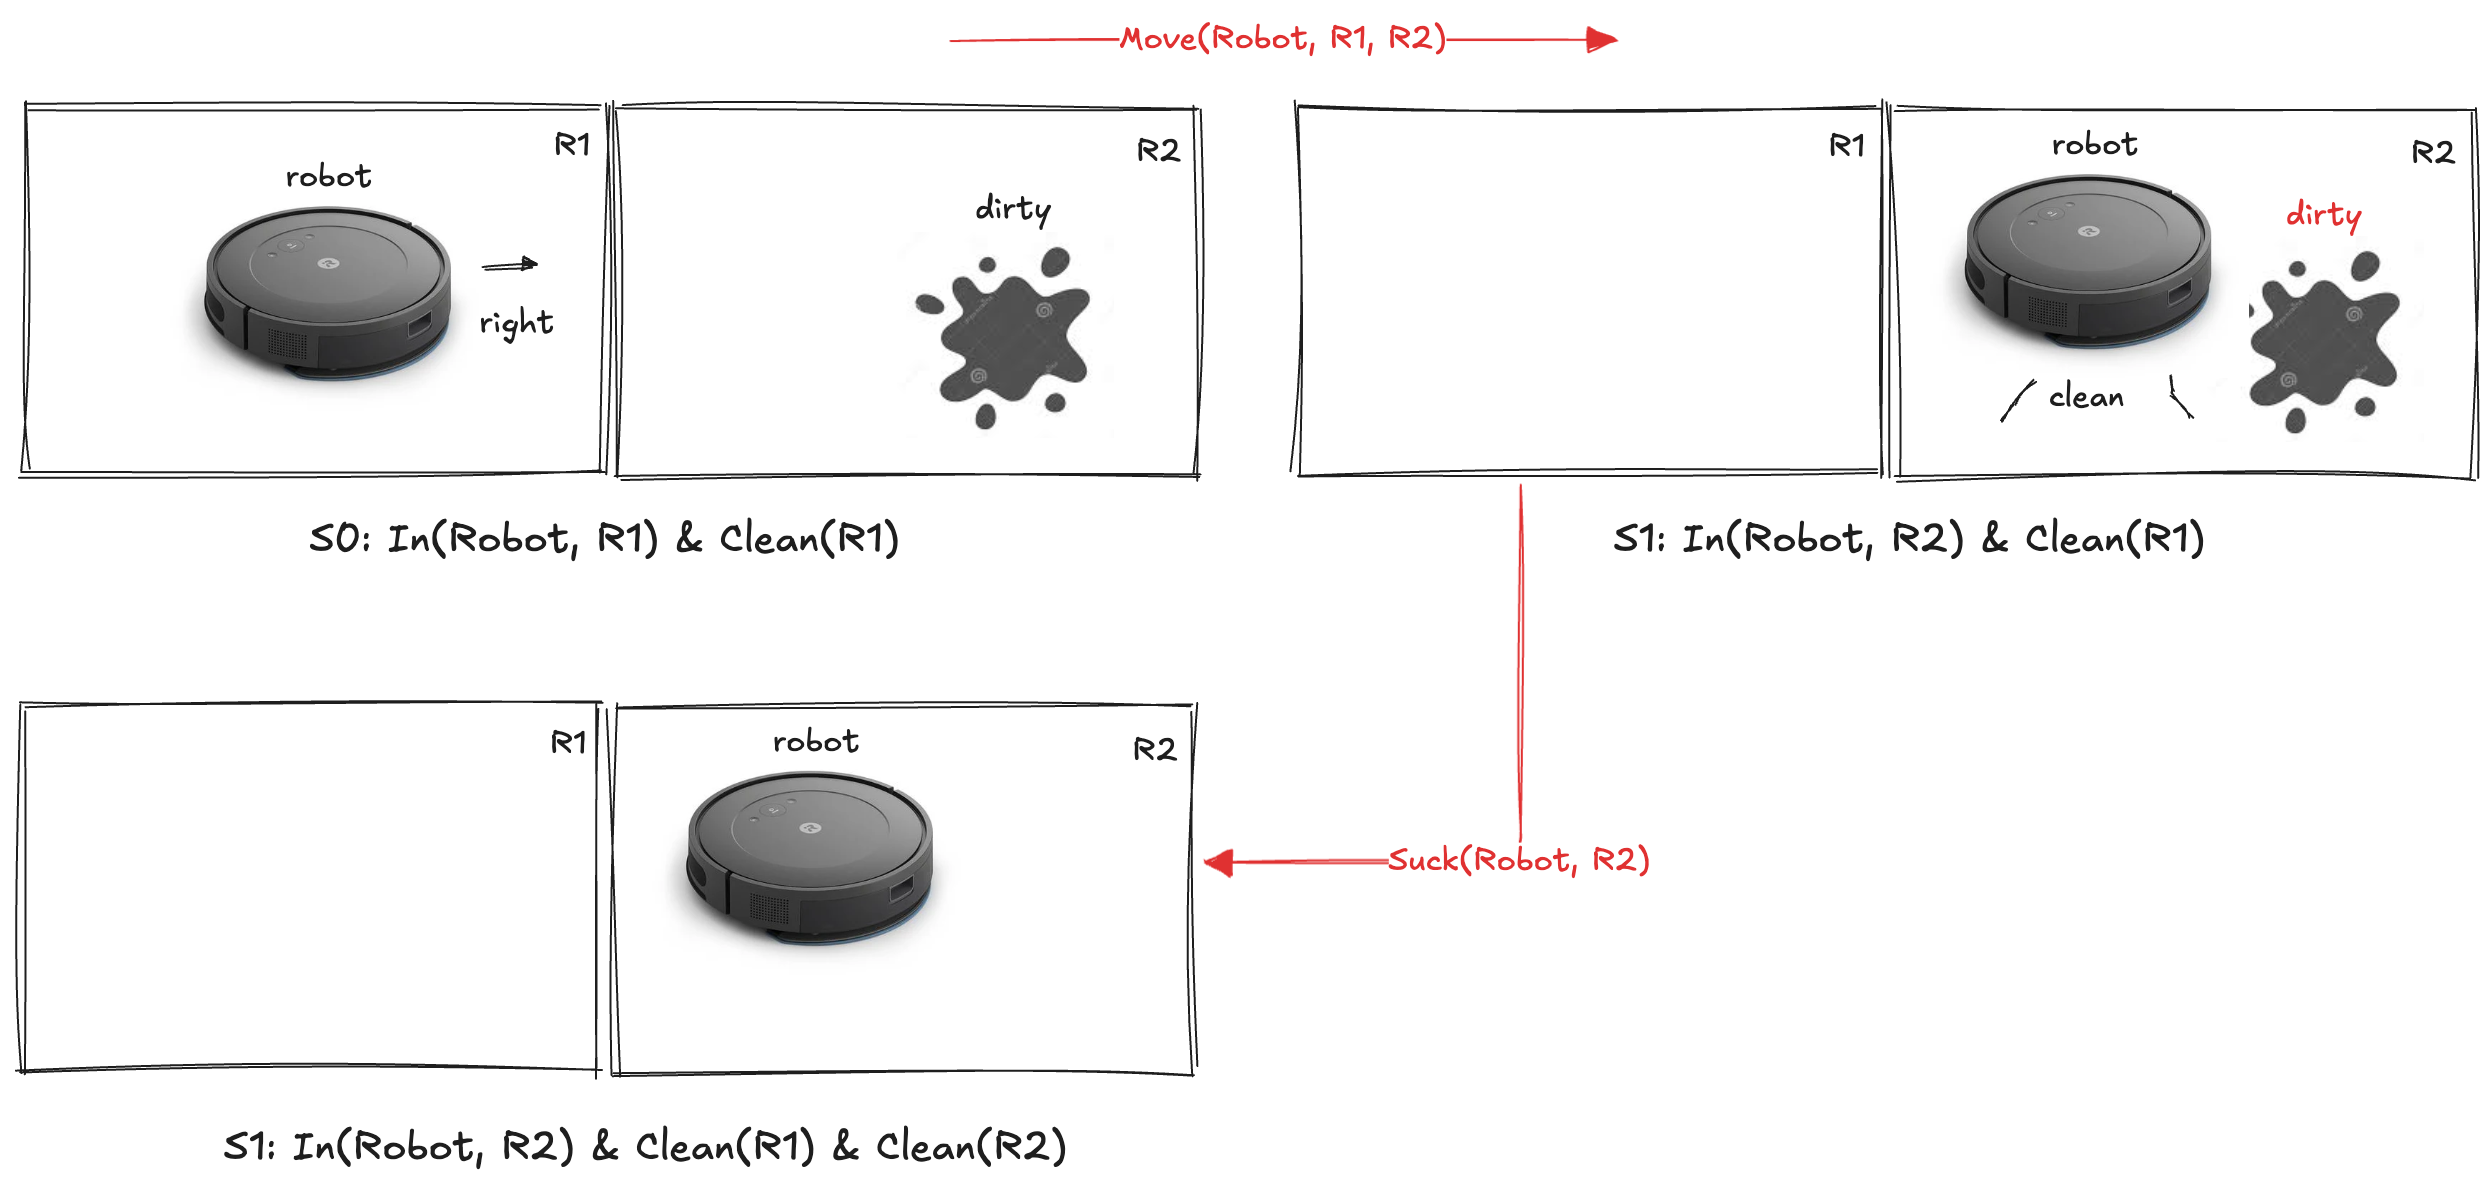 

In [227]:
# Plan
plan = [
    GroundedAction(Move, {
        "robot": Robot,
        "from_room": R1,
        "to_room": R2
    }),
    GroundedAction(Suck, {
        "robot": Robot,
        "room": R2
    })
]

We can write a funtion to **run a plan** in a given initial state, applying each action in sequence and returning the final state:

In [228]:
def run(plan, initial_state, verbose=True):

    # Start with the initial state  
    state = initial_state
    if verbose: print(f"Starting state: {state}\n")

    # Goes through each action in the plan
    for step, action in enumerate(plan):
        # Apply the action
        state = apply(action, state)
        if verbose: print(f"Next state: {state}\n")
    
    if verbose: print("Plan completed successfully.")
    return state

Check if the plan is a solution to the problem by verifying that the final state satisfies the goal condition:

In [229]:
final_state = run(plan, initial_state);

Starting state: { Clean(R1), In(Robot, R1) }

Next state: { Clean(R1), In(Robot, R2) }

Next state: { Clean(R1), Clean(R2), In(Robot, R2) }

Plan completed successfully.


Inspecting the final state, we can see that the vacuum cleaner sucessfully moved from R1 to R2, and both rooms are clean. However, we can write a function to automatically check if the plan is a solution to the problem by verifying that the final state satisfies the goal condition:

In [230]:
def check(state, goal):
    return (
        all(fluent in state.fluents for fluent in goal.get("positive", [])) and
        all(fluent not in state.fluents for fluent in goal.get("negative", []))
    )

In the example: 

In [231]:
check_result = check(final_state, goal)
print("Does the final state satisfy the goal?", check_result) 

Does the final state satisfy the goal? True


The PDDL language can be extended to support **equality predicates**, enabling the expression of conditions such as "the dirty is at the same location as the vacuum cleaner". This is particularly useful in domains where relationships between objects are important. Additionally, PDDL can **incorporate algebraic expressions** to represent numerical relationships, such as "the robot has cleaned 3 rooms". These numeric fluents are valuable in domains that involve quantities, like logistics or resource management. However, such features are generally not used in basic or introductory PDDL problems.

## Problem examples

To illustrate how planning works in practice, we now turn to a series of concrete problem examples that demonstrate how initial states, goals, and action schemas come together to define and solve planning tasks.

### Air Cargo Logistics Domain

The first concrete example is a simple **air cargo logistics domain**, where cargo must be transported between airports using planes. This domain include some objects: two airports, two planes, and two cargo:

In [232]:
C1 = Object("C1")
C2 = Object("C2")
P1 = Object("P1")
P2 = Object("P2")
JFK = Object("JFK")
MPX = Object("MPX")

We need to represent the position of an object (both cargo and planes) at a give location (an airport) and the nature of each each object (whether it is a plane, a cargo, or an airport). We can use the following predicates:

In [233]:
Cargo = Predicate("Cargo", 1)
Plane = Predicate("Plane", 1)
Airport = Predicate("Airport", 1)
At = Predicate("At", 2)
In = Predicate("In", 2)

The initial state describes the current configuration of the world, including the locations of planes and cargo, as well as the availability of planes at each airport:

In [234]:
initial_state = State([
    Fluent(Cargo, [C1]),
    Fluent(Cargo, [C2]),
    Fluent(Plane, [P1]),
    Fluent(Plane, [P2]),
    Fluent(Airport, [JFK]),
    Fluent(Airport, [MPX]),
    Fluent(At, [C1, MPX]),
    Fluent(At, [C2, JFK]),
    Fluent(At, [P1, MPX]),
    Fluent(At, [P2, JFK])
])

The goal condition specifies what we want cargo C1 to be at airport JFK and cargo C2 to be at airport MPX:

In [235]:
goal = {
    "positive": [
        Fluent(At, [C1, JFK]),
        Fluent(At, [C2, MPX])
    ],
    "negative": []
}

This domain includes three core action schemas. The Load action schema allows a plane to load cargo at an airport, provided the plane is at that airport and the cargo is also there. The resulting state will reflect that the cargo is no longer at the airport and it is now in the plane:

In [236]:
Load = ActionSchema(
    name="Load",
    parameters=["cargo", "plane", "airport"],

    pos_preconditions=[
        Fluent(Cargo, ["cargo"]),
        Fluent(Plane, ["plane"]),
        Fluent(Airport, ["airport"]),
        Fluent(At, ["cargo", "airport"]),
        Fluent(At, ["plane", "airport"])
    ],
    
    neg_preconditions=[],

    pos_effects=[
        Fluent(In, ["cargo", "plane"])
    ],
    
    neg_effects=[
        Fluent(At, ["cargo", "airport"])
    ]
)

The Unload action schema allows a plane to unload cargo at an airport, provided the plane is at that airport and the cargo is on the plane. The resulting state will reflect that the cargo is now at the airport and no longer on the plane:

In [237]:
Unload = ActionSchema(
    name="Unload",
    parameters=["cargo", "plane", "airport"],

    pos_preconditions=[
        Fluent(Cargo, ["cargo"]),
        Fluent(Plane, ["plane"]),
        Fluent(Airport, ["airport"]),
        Fluent(In, ["cargo", "plane"]),
        Fluent(At, ["plane", "airport"])
    ],

    neg_preconditions=[],

    pos_effects=[
        Fluent(At, ["cargo", "airport"])
    ],

    neg_effects=[
        Fluent(In, ["cargo", "plane"])
    ]
)

Finally, the Fly action schema allows a plane to fly from one airport to another, provided the plane is at the departure airport. The resulting state will reflect that the plane has moved to the destination airport:

In [238]:
Fly = ActionSchema(
    name="Fly",
    parameters=["plane", "origin", "destination"],

    pos_preconditions=[
        Fluent(Plane, ["plane"]),
        Fluent(Airport, ["origin"]),
        Fluent(Airport, ["destination"]),
        Fluent(At, ["plane", "origin"])
    ],

    neg_preconditions=[],

    pos_effects=[
        Fluent(At, ["plane", "destination"])
    ],

    neg_effects=[
        Fluent(At, ["plane", "origin"])
    ]
)

A plan to achieve the goal condition could load plane P1 with cargo C1 at airport JFK, fly to MPX, unload C1, then load P2 with C2 at MPX, and finally fly back to JFK:

In [239]:
plan = [
    # Step 1: Load C1 onto P1 at MPX
    GroundedAction(Load, {"cargo": C1, "plane": P1, "airport": MPX}),
    
    # Step 2: Fly P1 from MPX to JFK
    GroundedAction(Fly, {"plane": P1, "origin": MPX, "destination": JFK}),
    
    # Step 3: Unload C1 from P1 at JFK
    GroundedAction(Unload, {"cargo": C1, "plane": P1, "airport": JFK}),
    
    # Step 4: Load C2 onto P2 at JFK
    GroundedAction(Load, {"cargo": C2, "plane": P2, "airport": JFK}),
    
    # Step 5: Fly P2 from JFK to MPX
    GroundedAction(Fly, {"plane": P2, "origin": JFK, "destination": MPX}),
    
    # Step 6: Unload C2 from P2 at MPX
    GroundedAction(Unload, {"cargo": C2, "plane": P2, "airport": MPX})
]

Check if the plan is a solution to the problem by verifying that the final state satisfies the goal condition:

In [240]:
final_state = run(plan, initial_state);

Starting state: { Airport(JFK), Airport(MPX), At(C1, MPX), At(C2, JFK), At(P1, MPX), At(P2, JFK), Cargo(C1), Cargo(C2), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C2, JFK), At(P1, MPX), At(P2, JFK), Cargo(C1), Cargo(C2), In(C1, P1), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C2, JFK), At(P1, JFK), At(P2, JFK), Cargo(C1), Cargo(C2), In(C1, P1), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C1, JFK), At(C2, JFK), At(P1, JFK), At(P2, JFK), Cargo(C1), Cargo(C2), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C1, JFK), At(P1, JFK), At(P2, JFK), Cargo(C1), Cargo(C2), In(C2, P2), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C1, JFK), At(P1, JFK), At(P2, MPX), Cargo(C1), Cargo(C2), In(C2, P2), Plane(P1), Plane(P2) }

Next state: { Airport(JFK), Airport(MPX), At(C1, JFK), At(C2, MPX), At(P1, JFK), At(P2, MPX), Cargo(C1), Cargo(C2), Plane(P1), Plane(P2) }

Plan completed succe

This plan successfully transports cargo C1 from MPX to JFK, and cargo C2 from JFK to MPX, using planes P1 and P2 respectively:

In [241]:
check_result = check(final_state, goal)
print("Does the final state satisfy the goal?", check_result)   

Does the final state satisfy the goal? True


### Flat Tire Replacement Problem

A second illustrative planning domain is the classic **flat tire replacement problem**. The objective is to install a good spare tire onto the car’s axle, starting from an initial state where a flat tire is already mounted, and the spare is stored in the trunk:

In [242]:
# Define objects
Flat = Object("Flat")
Spare = Object("Spare")
Axle = Object("Axle")
Trunk = Object("Trunk")
Ground = Object("Ground")

In [243]:
# Predicates
Tire = Predicate("Tire", 1)
Location = Predicate("Location", 1)
At = Predicate("At", 2)

In [244]:
# Initial state
initial_state = State([
    Fluent(Tire, [Flat]),
    Fluent(Tire, [Spare]),
    Fluent(Location, [Axle]),
    Fluent(Location, [Trunk]),
    Fluent(Location, [Ground]),
    Fluent(At, [Flat, Axle]),
    Fluent(At, [Spare, Trunk])
])

In [245]:
# The goal
goal = {
    "positive": [
        Fluent(At, [Spare, Axle])
    ],
    "negative": []
}

This version abstracts away real-world complications focusing purely on symbolic actions. The domain includes the following actions. First it is possible to remove any object from a location (e.g., from the trunk or the axle):

In [246]:
Remove = ActionSchema(
    name="Remove",
    parameters=["item", "location"],
    pos_preconditions=[
        Fluent(At, ["item", "location"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(At, ["item", "Ground"])  # use variable name as string
    ],
    neg_effects=[
        Fluent(At, ["item", "location"])
    ]
)

Then it is possible to install a tire onto the axle:

In [247]:
PutOn = ActionSchema(
    name="PutOn",
    parameters=["tire", "axle"],
    pos_preconditions=[
        Fluent(Tire, ["tire"]),
        Fluent(At, ["tire", "Ground"])
    ],
    neg_preconditions=[
        Fluent(At, [Flat, Axle]),
        Fluent(At, [Spare, Axle])
    ],
    pos_effects=[
        Fluent(At, ["tire", "axle"])
    ],
    neg_effects=[
        Fluent(At, ["tire", "Ground"])
    ]
)

Finally, we can leave the car unattended overnight, with unfortunate consequences (we assume the car is parked in a bad neighborhood, where leaving it overnight causes all spare tires to disappear, no matter where they are):

In [248]:
LeaveOvernight = ActionSchema(
    name="LeaveOvernight",
    parameters=[],
    pos_preconditions=[],
    neg_preconditions=[],
    pos_effects=[],
    neg_effects=[
        Fluent(At, [Spare, Ground]),
        Fluent(At, [Spare, Axle]),
        Fluent(At, [Spare, Trunk])
    ]
)

A solution to this problem is the following plan:

In [249]:
plan = [
    GroundedAction(Remove, {"item": Flat, "location": Axle}),
    GroundedAction(Remove, {"item": Spare, "location": Trunk}),
    GroundedAction(PutOn, {"tire": Spare, "axle": Axle})
]

This plan first removes the flat tire from the axle, then takes the spare out of the trunk, and finally mounts the spare onto the axle, achieving the goal. Let's check:

In [250]:
final_state = run(plan, initial_state)
check_result = check(final_state, goal)
print("Does the final state satisfy the goal?", check_result)  

Starting state: { At(Flat, Axle), At(Spare, Trunk), Location(Axle), Location(Ground), Location(Trunk), Tire(Flat), Tire(Spare) }

Next state: { At(Flat, Ground), At(Spare, Trunk), Location(Axle), Location(Ground), Location(Trunk), Tire(Flat), Tire(Spare) }

Next state: { At(Flat, Ground), At(Spare, Ground), Location(Axle), Location(Ground), Location(Trunk), Tire(Flat), Tire(Spare) }

Next state: { At(Flat, Ground), At(Spare, Axle), Location(Axle), Location(Ground), Location(Trunk), Tire(Flat), Tire(Spare) }

Plan completed successfully.
Does the final state satisfy the goal? True


### Blocks World

One of the most well-known and widely studied planning domains is the **Blocks World**. It features a set of labeled cube-shaped blocks resting on a large table:

In [251]:
A = Object("A")
B = Object("B")
C = Object("C")
Table = Object("Table")

These blocks can be stacked on top of one another, but only one block can occupy the top of another at any given time. A robot arm is responsible for manipulating the blocks. It can:
- Pick up a block from the table or from the top of another block
- Place a block either on the table or on top of another block

However, the robot arm has certain limitations:
- It can hold only one block at a time
- It cannot pick up a block that has another block on top of it

This introduces a natural **hierarchy of dependencies** between actions: some blocks must be cleared before others can be moved. A typical goal is to achieve a specific stacking configuration. For example:

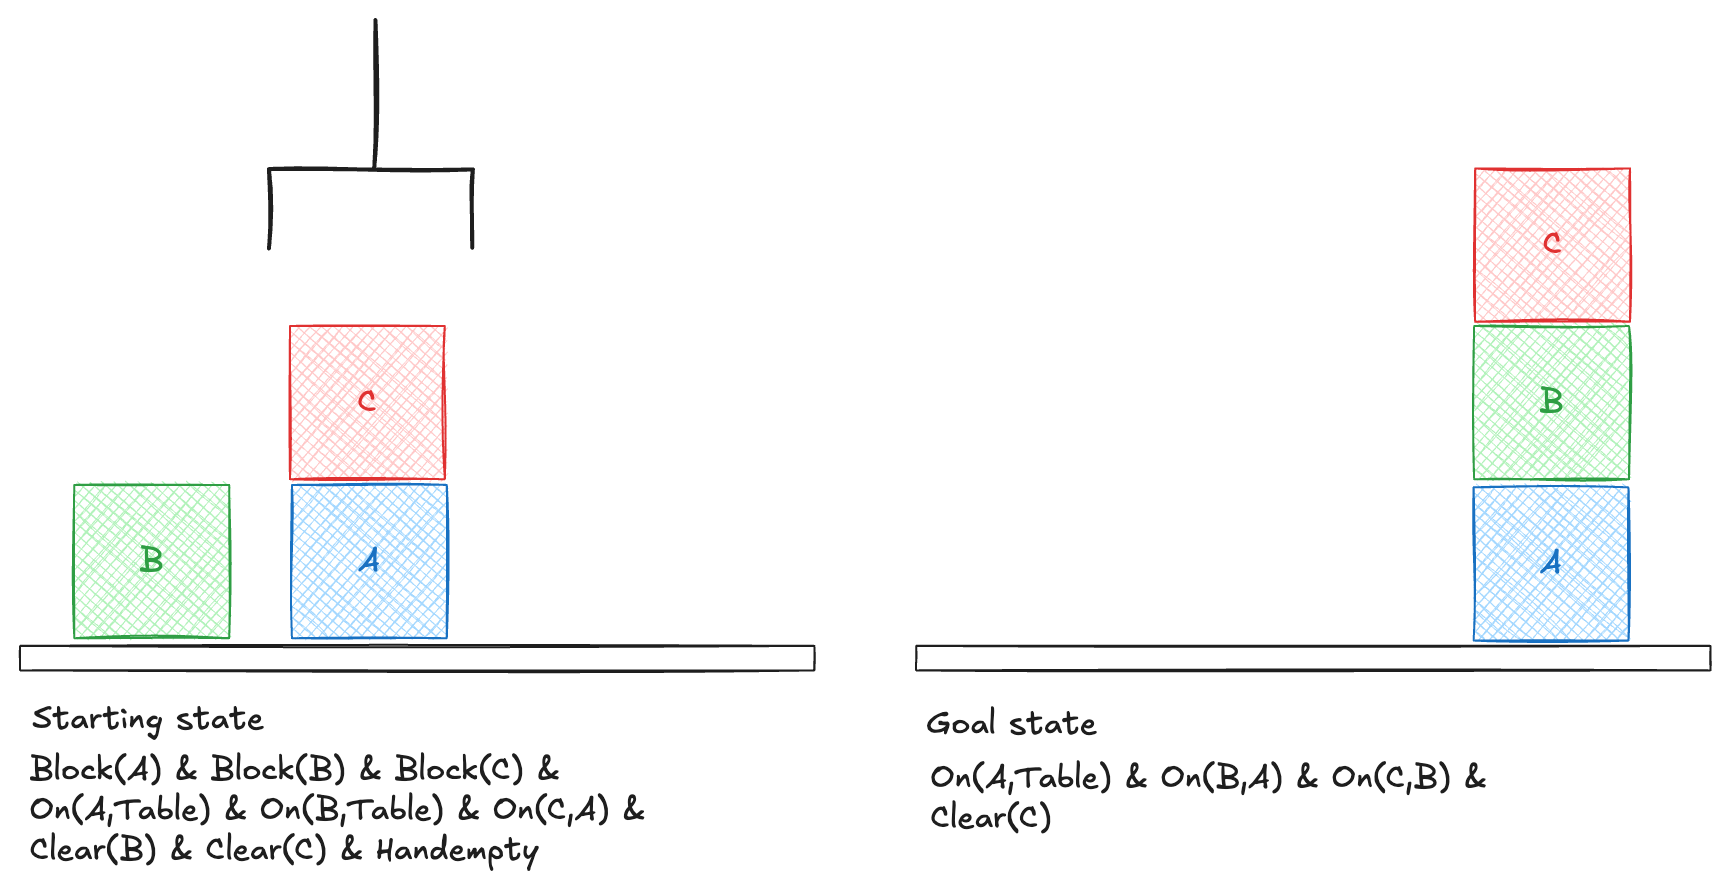

The predicates used in this domain include the position of each block (whether it is on the table or on top of another block), the robot harm current holding state, and the state of the blocks (whether they are clear or not):

In [252]:
Block = Predicate("Block", 1)
Handempty = Predicate("Handempty", 0)
Clear = Predicate("Clear", 1)
On = Predicate("On", 2)
Holding = Predicate("Holding", 1)

Let's start consideting the initial state and the goal state:

In [253]:
initial_state = State([
    Fluent(Block, [A]),
    Fluent(Block, [B]),
    Fluent(Block, [C]),
    Fluent(Handempty, []),
    Fluent(On, [A, Table]),
    Fluent(On, [B, Table]),
    Fluent(On, [C, A]),
    Fluent(Clear, [C]),
    Fluent(Clear, [B])
])

In [254]:
goal = {
    "positive": [
        Fluent(On, [A, Table]),
        Fluent(On, [B, A]),
        Fluent(On, [C, B]),
        Fluent(Clear, [C])
    ],
    "negative": []
}

Now, we can define an action schema to allow the robot arm wants to pick up a block that is stacked on another block, placing it in the robot’s hand. We need to ensure that the block is clear (i.e., no other block is on top of it) and that the robot arm is not already holding another block: 

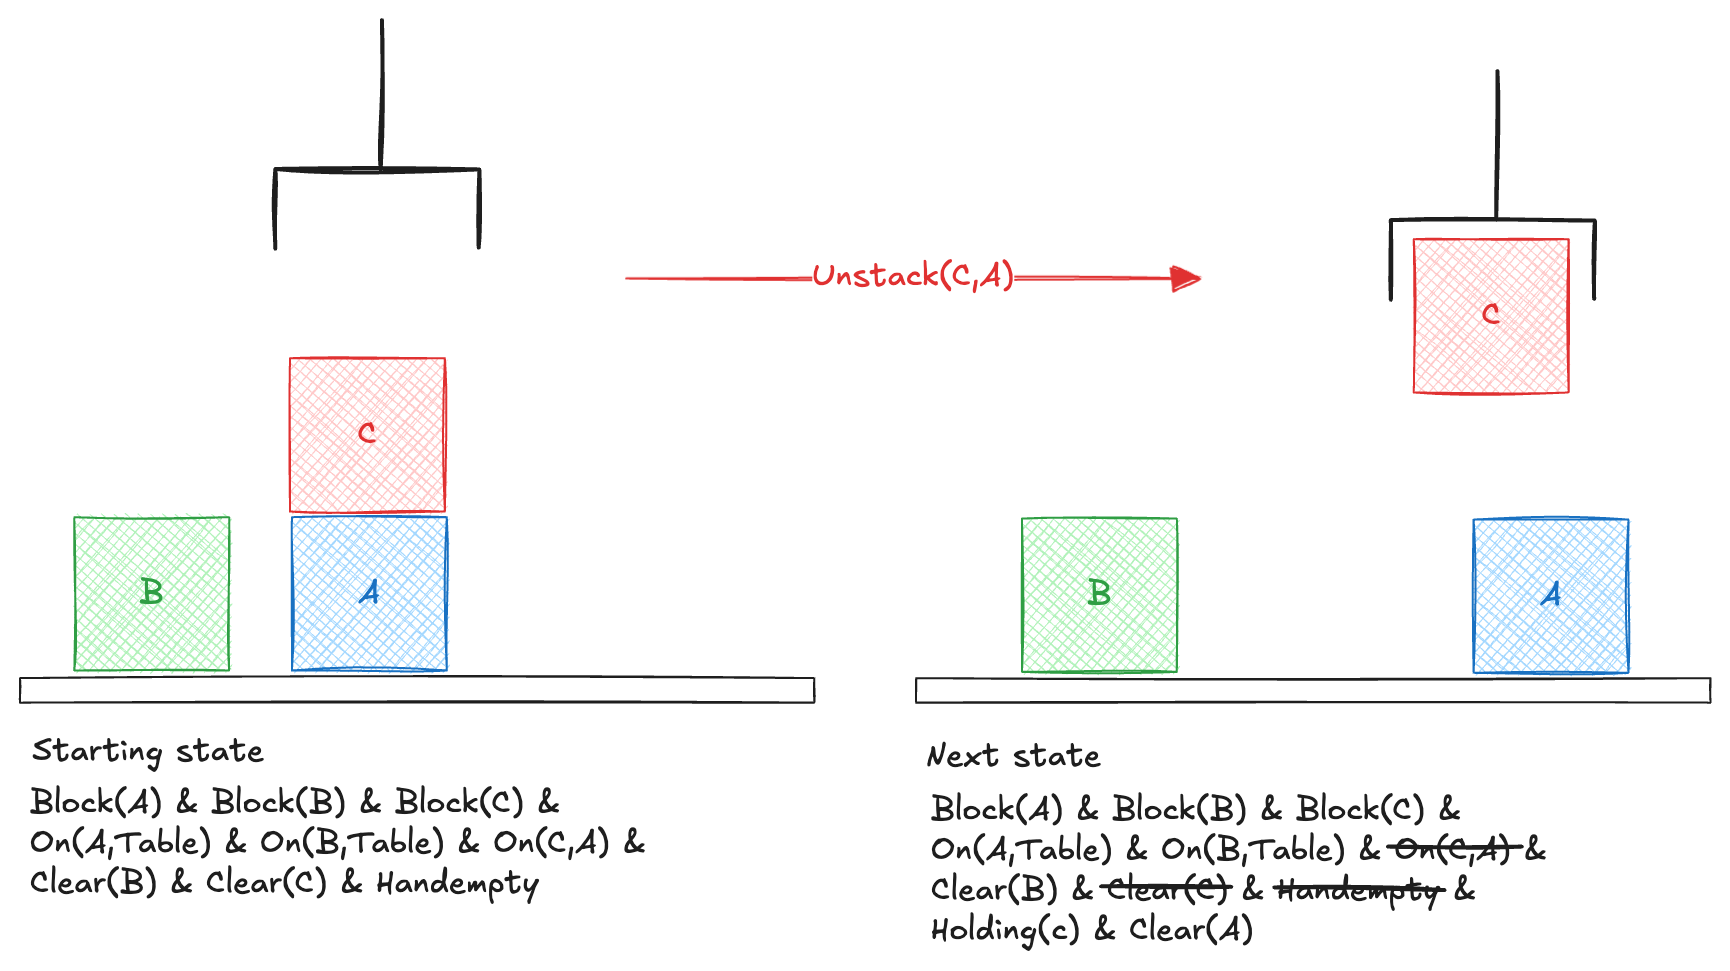

In [255]:
Unstack = ActionSchema(
    name="Unstack",
    parameters=["top_block", "bottom_block"],
    pos_preconditions=[
        Fluent(Handempty, []),
        Fluent(Block, ["top_block"]),
        Fluent(Block, ["bottom_block"]),
        Fluent(Clear, ["top_block"]),
        Fluent(On, ["top_block", "bottom_block"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(Holding, ["top_block"]),
        Fluent(Clear, ["bottom_block"])
    ],
    neg_effects=[
        Fluent(Handempty, []),
        Fluent(Clear, ["top_block"]),
        Fluent(On, ["top_block", "bottom_block"])
    ]
)

We also define action schemas to place a block onto another target block, releasing it from the robot’s hand; lift a clear block from the table into the robot’s hand, assuming the hand is empty; and put down a block from the robot’s hand onto the table, making it clear and freeing the hand.

In [256]:
Stack = ActionSchema(
    name="Stack",
    parameters=["held_block", "target_block"],
    pos_preconditions=[
        Fluent(Holding, ["held_block"]),
        Fluent(Block, ["held_block"]),
        Fluent(Block, ["target_block"]),
        Fluent(Clear, ["target_block"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(On, ["held_block", "target_block"]),
        Fluent(Clear, ["held_block"]),
        Fluent(Handempty, [])
    ],
    neg_effects=[
        Fluent(Holding, ["held_block"]),
        Fluent(Clear, ["target_block"])
    ]
)

In [257]:
Pickup = ActionSchema(
    name="Pickup",
    parameters=["block"],
    pos_preconditions=[
        Fluent(Handempty, []),
        Fluent(Block, ["block"]),
        Fluent(Clear, ["block"]),
        Fluent(On, ["block", Table])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(Holding, ["block"])
    ],
    neg_effects=[
        Fluent(Handempty, []),
        Fluent(Clear, ["block"]),
        Fluent(On, ["block", Table])
    ]
)

In [258]:
Putdown = ActionSchema(
    name="Putdown",
    parameters=["held_block"],
    pos_preconditions=[
        Fluent(Holding, ["held_block"]),
        Fluent(Block, ["held_block"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(On, ["held_block", Table]),
        Fluent(Clear, ["held_block"]),
        Fluent(Handempty, [])
    ],
    neg_effects=[
        Fluent(Holding, ["held_block"])
    ]
)

To solve the exmaple problem, we can use the following plan:

In [259]:
plan = [
    GroundedAction(Unstack, {"top_block": C, "bottom_block": A}),
    GroundedAction(Putdown, {"held_block": C}),
    
    GroundedAction(Pickup, {"block": B}),
    GroundedAction(Stack, {"held_block": B, "target_block": A}),
    
    GroundedAction(Pickup, {"block": C}),
    GroundedAction(Stack, {"held_block": C, "target_block": B})
]

In [260]:
final_state = run(plan, initial_state)
check_result = check(final_state, goal)
print("Does the final state satisfy the goal?", check_result)

Starting state: { Block(A), Block(B), Block(C), Clear(B), Clear(C), Handempty(), On(A, Table), On(B, Table), On(C, A) }

Next state: { Block(A), Block(B), Block(C), Clear(A), Clear(B), Holding(C), On(A, Table), On(B, Table) }

Next state: { Block(A), Block(B), Block(C), Clear(A), Clear(B), Clear(C), Handempty(), On(A, Table), On(B, Table), On(C, Table) }

Next state: { Block(A), Block(B), Block(C), Clear(A), Clear(C), Holding(B), On(A, Table), On(C, Table) }

Next state: { Block(A), Block(B), Block(C), Clear(B), Clear(C), Handempty(), On(A, Table), On(B, A), On(C, Table) }

Next state: { Block(A), Block(B), Block(C), Clear(B), Holding(C), On(A, Table), On(B, A) }

Next state: { Block(A), Block(B), Block(C), Clear(C), Handempty(), On(A, Table), On(B, A), On(C, B) }

Plan completed successfully.
Does the final state satisfy the goal? True


### Key-in-box Problem

The **key-in-box problem** is a classic planning scenario involving a robot, a key, a lockable door, and a box.

XXX disegno

In [261]:
Robot = Object("Robot")
Key = Object("Key")
Door = Object("Door")
Box = Object("Box")
R1 = Object("R1")
R2 = Object("R2")

The robot must lock the door and place the key into the box, but since the key is required to lock or unlock the door, the sequence of actions must be carefully planned. Once the key is placed in the box, it becomes inaccessible to the robot. The robot is capable of picking up the key, depositing it in the box, moving between rooms, and operating the door, provided it holds the key when locking or unlocking it.

In [262]:
In = Predicate("In", 2)             # In(x, room)
Has = Predicate("Has", 2)           # Has(agent, object)
Open = Predicate("Open", 1)         # Open(door)
Locked = Predicate("Locked", 1)     # Locked(door)
InBox = Predicate("InBox", 1)       # InBox(object)

The inizial state of the world is as follows:

In [263]:
initial_state = State([
    Fluent(In, [Robot, R2]),
    Fluent(In, [Key, R2]),
    Fluent(Open, [Door])
])

The gola is to have the key in the box and the door locked:

In [264]:
goal = {
    "positive": [
        Fluent(Locked, [Door]),
        Fluent(InBox, [Key])
    ],
    "negative": []
}

The agent che pickup the key, 

In [265]:
Pickup = ActionSchema(
    name="Pickup",
    parameters=["agent", "item", "location"],
    pos_preconditions=[
        Fluent(In, ["agent", "location"]),
        Fluent(In, ["item", "location"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(Has, ["agent", "item"])
    ],
    neg_effects=[
        Fluent(In, ["item", "location"])
    ]
)

In [266]:
Move = ActionSchema(
    name="Move",
    parameters=["agent", "from_room", "to_room"],
    pos_preconditions=[
        Fluent(In, ["agent", "from_room"]),
        Fluent(Open, [Door])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(In, ["agent", "to_room"])
    ],
    neg_effects=[
        Fluent(In, ["agent", "from_room"])
    ]
)

In [267]:
LockDoor = ActionSchema(
    name="LockDoor",
    parameters=["agent", "door", "key"],
    pos_preconditions=[
        Fluent(Has, ["agent", "key"]),
        Fluent(Open, ["door"])
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(Locked, ["door"])
    ],
    neg_effects=[
        Fluent(Open, ["door"])
    ]
)

In [268]:
PutInBox = ActionSchema(
    name="PutInBox",
    parameters=["agent", "item", "box"],
    pos_preconditions=[
        Fluent(Has, ["agent", "item"]),
        Fluent(In, ["agent", R1])  # mailbox is in R1
    ],
    neg_preconditions=[],
    pos_effects=[
        Fluent(InBox, ["item"])
    ],
    neg_effects=[
        Fluent(Has, ["agent", "item"])
    ]
)

In [269]:
plan = [
    GroundedAction(Pickup, {"agent": Robot, "item": Key, "location": R2}),
    GroundedAction(Move, {"agent": Robot, "from_room": R2, "to_room": R1}),
    GroundedAction(LockDoor, {"agent": Robot, "door": Door, "key": Key}),
    GroundedAction(PutInBox, {"agent": Robot, "item": Key, "box": Box})
]

In [270]:
final_state = run(plan, initial_state)
check_result = check(final_state, goal)
print("Does the final state satisfy the goal?", check_result)

Starting state: { In(Key, R2), In(Robot, R2), Open(Door) }

Next state: { Has(Robot, Key), In(Robot, R2), Open(Door) }

Next state: { Has(Robot, Key), In(Robot, R1), Open(Door) }

Next state: { Has(Robot, Key), In(Robot, R1), Locked(Door) }

Next state: { In(Robot, R1), InBox(Key), Locked(Door) }

Plan completed successfully.
Does the final state satisfy the goal? True


## Forward state-space search

The description of a planning problem **naturally supports forward search**: starting from the initial state, we can explore the space of possible states to find one that satisfies the goal. We can solve the planning problems by applying any of the **heuristic search algorithms**. The states in this search state space are ground states, where every fluent is either true or not. The goal is a state that has all the positive fluents in the problem’s goal and none of the negative fluents. The applicable actions in a state are grounded instantiations of the action schemas, where the variables have all
been replaced by constant values. To determine the applicable actions we unify the current state against the preconditions of each action schema. For each unification that successfully results in a substitution, we apply the substitution to the action schema to yield a ground action with no variables. (It
is a requirement of action schemas that any variable in the effect must also appear in the
precondition; that way, we are guaranteed that no variables remain after the substitution.)
Each schema may unify in multiple ways. In the spare tire example (page 346), the
Remove action has the precondition At(obj, loc), which matches against the initial state in two
ways, resulting in the two substitutions {obj/Flat, loc/Axle} and {obj/Spare, loc/Trunk};
applying these substitutions yields two ground actions. If an action has multiple literals in
the precondition, then each of them can potentially be matched against the current state in
multiple ways.
At first, it seems that the state space might be too big for many problems. Consider an
air cargo problem with 10 airports, where each airport initially has 5 planes and 20 pieces of
cargo. The goal is to move all the cargo at airport A to airport B. There is a 41-step solution
to the problem: load the 20 pieces of cargo into one of the planes at A, fly the plane to B, and
unload the 20 pieces.
Finding this apparently straightforward solution can be difficult because the average
branching factor is huge: each of the 50 planes can fly to 9 other airports, and each of the 200
packages can be either unloaded (if it is loaded) or loaded into any plane at its airport (if it
is unloaded). So in any state there is a minimum of 450 actions (when all the packages are
at airports with no planes) and a maximum of 10,450 (when all packages and planes are at

One of the key advantages of using a declarative representation with action schemas is that it also enables backward search—starting from the goal and reasoning in reverse to identify a sequence of actions that could lead to it. 

A third approach is to translate the entire problem into a set of logical sentences and apply inference algorithms to derive a solution through logical reasoning.

Goals **may also contain variables**. For example, Clean(x) is satisfied in a state S if there exists at least one ground fluent in S that matches (unifies with) Clean(x).